Cell 1 -- imports + 常数

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import pathlib, datetime

F = 96485.33212      # C/mol
R = 8.314462618      # J/mol/K
eps0 = 8.8541878128e-12  # F/m


Cell 2 -- 一键改参数的地方 (BASE_PARAMS)

In [2]:
BASE_PARAMS = dict(
    # ---------- Electrolyte ----------
    T=298.15,
    epsilon_r=78.5,          # relative permittivity (water ~78.5 at RT)
    ionic_strength_M=0.1,    # mol/L (if lambda_D_m is None)
    lambda_D_m=None,         # override Debye length directly (m). If set, ionic_strength_M is ignored.

    # ---------- Geometry / Structure (particle size & spacing) ----------
    # Provide lengths in nm (or use *_m in meters)
    L_Au_nm=5.0,  L_Au_m=None,
    L_gap_nm=2.0,  L_gap_m=None,   # separation (support segment length between Au and Pd)
    L_Pd_nm=3.0,  L_Pd_m=None,

    # ---------- Materials (support/material parameters) ----------
    pzc_Au_V=0.0,
    pzc_C_V=0.2,
    pzc_Pd_V=0.0,

    Cdl_Au=0.025,   # F/m^2   (25 µF/cm^2 = 0.25 F/m^2)
    Cdl_C=0.10,
    Cdl_Pd=0.15,

    # ---------- Kinetics ----------
    i0_1=1.0,       # prefactor for half-reaction 1 (arbitrary scale is fine)
    i0_2=1.0,       # prefactor for half-reaction 2
    Eeq1_V=-0.2,    # equilibrium potential of half-reaction 1
    Eeq2_V=0.2,     # equilibrium potential of half-reaction 2
    alpha1=0.5,
    alpha2=0.5,
    z_R1=0.0,       # charge of R1 at reaction plane
    z_O2=0.0,       # charge of O2 at reaction plane
)


Cell 3 — 核心模型类（EDL + mixed potential + 输出 K、a_weighted、斜率等）

In [3]:
def debye_length(ionic_strength_M: float, T: float, epsilon_r: float) -> float:
    """Debye length (m) for symmetric 1:1 electrolyte; ionic_strength_M in mol/L."""
    I_m3 = ionic_strength_M * 1000.0  # mol/m^3
    return math.sqrt(epsilon_r * eps0 * R * T / (2.0 * F**2 * I_m3))


class EDLMixedPotentialModel:
    """
    Implements your SI structure:
      - S1: Debye–Hückel + Robin BC with segment-specific (Cdl, pzc) solved by cosine/Galerkin
      - S2/S3: EDL-modified (single-exponential) half-reaction currents
      - S3: mixed potential: ∫Au i1 dx + ∫Pd i2 dx = 0
      - S5: K_Au, K_Pd, a_weighted, d ln i / dE
    """

    def __init__(self, params: dict, N_modes: int = 60, Nx: int = 2000):
        self.params = params.copy()
        self.N_modes = int(N_modes)
        self.Nx = int(Nx)
        self._build()

    def _build(self):
        p = self.params
        self.T = float(p["T"])
        self.epsilon_r = float(p["epsilon_r"])
        self.epsilon_s = self.epsilon_r * eps0

        # Debye length
        if p.get("lambda_D_m") is not None:
            self.lambda_D = float(p["lambda_D_m"])
        else:
            self.lambda_D = debye_length(float(p["ionic_strength_M"]), self.T, self.epsilon_r)

        # geometry (nm or m)
        def get_len(key_m, key_nm):
            if key_m in p and p[key_m] is not None:
                return float(p[key_m])
            if key_nm in p and p[key_nm] is not None:
                return float(p[key_nm]) * 1e-9
            raise KeyError(f"Need {key_m} or {key_nm}")

        self.L_Au = get_len("L_Au_m", "L_Au_nm")
        self.L_gap = get_len("L_gap_m", "L_gap_nm")
        self.L_Pd = get_len("L_Pd_m", "L_Pd_nm")
        self.L_total = self.L_Au + self.L_gap + self.L_Pd
        self.L_C = self.L_Au + self.L_gap

        # dimensionless lengths
        self.Lt_Au = self.L_Au / self.lambda_D
        self.Lt_C = self.L_C / self.lambda_D
        self.Lt_total = self.L_total / self.lambda_D

        # materials
        self.Cdl_Au = float(p["Cdl_Au"])
        self.Cdl_C  = float(p["Cdl_C"])
        self.Cdl_Pd = float(p["Cdl_Pd"])
        self.pzc_Au = float(p["pzc_Au_V"])
        self.pzc_C  = float(p["pzc_C_V"])
        self.pzc_Pd = float(p["pzc_Pd_V"])

        # dimensionless g = lambda_D Cdl / epsilon_s
        self.g_Au = self.lambda_D * self.Cdl_Au / self.epsilon_s
        self.g_C  = self.lambda_D * self.Cdl_C  / self.epsilon_s
        self.g_Pd = self.lambda_D * self.Cdl_Pd / self.epsilon_s

        # dimensionless pzc:  phi_pzc~ = F pzc / RT
        self.phi_pzc_Au = F * self.pzc_Au / (R * self.T)
        self.phi_pzc_C  = F * self.pzc_C  / (R * self.T)
        self.phi_pzc_Pd = F * self.pzc_Pd / (R * self.T)

        # kinetics
        self.i0_1 = float(p["i0_1"])
        self.i0_2 = float(p["i0_2"])
        self.Eeq1 = float(p["Eeq1_V"])
        self.Eeq2 = float(p["Eeq2_V"])
        self.alpha1 = float(p["alpha1"])
        self.alpha2 = float(p["alpha2"])
        self.z_R1 = float(p["z_R1"])
        self.z_O2 = float(p["z_O2"])

        # Gamma factors as in your SI:
        self.Gamma1 = (1.0 - self.alpha1) + self.z_R1
        self.Gamma2 = self.alpha2 - self.z_O2
        self.kappa = (1.0 - self.alpha1) + self.alpha2

        # Precompute affine EDL mapping: phi2~(x;E) = a(x)*phiM~ + b(x)
        self._precompute_affine_maps()

    def _precompute_affine_maps(self):
        N = self.N_modes
        L = self.Lt_total

        n = np.arange(N+1, dtype=float)
        rho = n * math.pi / L
        gamma = np.sqrt(1.0 + rho**2)
        gamma[0] = 1.0

        # integrals
        def int_cos(k, a, b):
            if abs(k) < 1e-14:
                return b - a
            return (math.sin(k*b) - math.sin(k*a)) / k

        def int_cos_cos(km, kn, a, b):
            if abs(km-kn) < 1e-14:
                if abs(km) < 1e-14:
                    return b - a
                return 0.5*(b - a) + 0.25*(math.sin(2*km*b)-math.sin(2*km*a))/km
            return 0.5*(int_cos(km-kn, a, b) + int_cos(km+kn, a, b))

        segs = [
            (0.0,        self.Lt_Au,   self.g_Au, self.phi_pzc_Au),
            (self.Lt_Au, self.Lt_C,    self.g_C,  self.phi_pzc_C),
            (self.Lt_C,  self.Lt_total,self.g_Pd, self.phi_pzc_Pd),
        ]

        S = np.zeros((N+1, N+1), dtype=float)
        Gvec = np.zeros(N+1, dtype=float)
        Pvec = np.zeros(N+1, dtype=float)

        for m in range(N+1):
            if m == 0:
                w_pref = 1.0 / L
                G_int = sum(g*(b-a) for (a,b,g,_) in segs)
                P_int = sum(g*pzc*(b-a) for (a,b,g,pzc) in segs)
                Gvec[m] = w_pref * G_int
                Pvec[m] = w_pref * P_int
                for n_idx in range(N+1):
                    kn = rho[n_idx]
                    I = sum(g*int_cos(kn, a, b) for (a,b,g,_) in segs)
                    S[m, n_idx] = w_pref * I
            else:
                w_pref = 2.0 / L
                km = rho[m]
                G_int = sum(g*int_cos(km, a, b) for (a,b,g,_) in segs)
                P_int = sum(g*pzc*int_cos(km, a, b) for (a,b,g,pzc) in segs)
                Gvec[m] = w_pref * G_int
                Pvec[m] = w_pref * P_int
                for n_idx in range(N+1):
                    kn = rho[n_idx]
                    I = sum(g*int_cos_cos(km, kn, a, b) for (a,b,g,_) in segs)
                    S[m, n_idx] = w_pref * I

        M = np.diag(gamma) + S

        # A(phiM~) = phiM~ * solve(M,G) - solve(M,P)
        self._A_M = np.linalg.solve(M, Gvec)
        self._A_0 = -np.linalg.solve(M, Pvec)

        # x-grid (dimensionless)
        self.x = np.linspace(0.0, self.Lt_total, self.Nx)
        self.cosm = np.cos(np.outer(np.arange(N+1), math.pi * self.x / self.Lt_total))

        # affine maps on reaction plane
        self.a_x = self._A_M @ self.cosm
        self.b_x = self._A_0 @ self.cosm

        # segment masks
        self.mask_Au = (self.x >= 0.0) & (self.x <= self.Lt_Au + 1e-12)
        self.mask_C  = (self.x >= self.Lt_Au - 1e-12) & (self.x <= self.Lt_C + 1e-12)
        self.mask_Pd = (self.x >= self.Lt_C - 1e-12) & (self.x <= self.Lt_total + 1e-12)

    def phi2_tilde(self, E_V: float) -> np.ndarray:
        """phi2~ = F*phi2/(RT) at reaction plane."""
        phiM_tilde = F * E_V / (R * self.T)
        return self.a_x * phiM_tilde + self.b_x

    def K_and_weighted_a(self, E_V: float):
        """Return K_Au(E), K_Pd(E), a_weighted_Au(E), a_weighted_Pd(E)."""
        phi2 = self.phi2_tilde(E_V)

        x_Au = self.x[self.mask_Au]
        w_Au = np.exp(-self.Gamma1 * phi2[self.mask_Au])
        K_Au = np.trapz(w_Au, x_Au)
        aW_Au = np.trapz(self.a_x[self.mask_Au] * w_Au, x_Au) / K_Au

        x_Pd = self.x[self.mask_Pd]
        w_Pd = np.exp(self.Gamma2 * phi2[self.mask_Pd])
        K_Pd = np.trapz(w_Pd, x_Pd)
        aW_Pd = np.trapz(self.a_x[self.mask_Pd] * w_Pd, x_Pd) / K_Pd

        return K_Au, K_Pd, aW_Au, aW_Pd

    def currents(self, E_V: float):
        """Integrated currents I1(E), I2(E), and Itot(E)=I1+I2."""
        K_Au, K_Pd, aW_Au, aW_Pd = self.K_and_weighted_a(E_V)
        beta = F / (R * self.T)

        # your SI single-exponential forms
        I1 = self.i0_1 * np.exp((1.0 - self.alpha1) * beta * (E_V - self.Eeq1)) * K_Au
        I2 = -self.i0_2 * np.exp(-self.alpha2 * beta * (E_V - self.Eeq2)) * K_Pd
        return I1, I2, I1 + I2, K_Au, K_Pd, aW_Au, aW_Pd

    def guess_E_mix(self):
        """Initial guess ignoring EDL weighting: K_Au≈L_Au~, K_Pd≈L_Pd~."""
        beta = F / (R * self.T)
        L_Au_t = self.Lt_Au
        L_Pd_t = self.Lt_total - self.Lt_C
        log_ratio = math.log((self.i0_2 * L_Pd_t) / (self.i0_1 * L_Au_t))
        return ((1.0 - self.alpha1) * self.Eeq1 + self.alpha2 * self.Eeq2 + (1.0 / beta) * log_ratio) / self.kappa

    def find_E_mix(self, E_min=None, E_max=None, tol_E=1e-8, tol_f=1e-12, max_iter=200):
        """Bisection with automatic bracketing."""
        if E_min is None or E_max is None:
            E0 = self.guess_E_mix()
            a, b = E0 - 0.5, E0 + 0.5
        else:
            a, b = E_min, E_max

        fa = self.currents(a)[2]
        fb = self.currents(b)[2]

        # expand bracket
        expand = 0
        while fa * fb > 0 and expand < 30:
            expand += 1
            width = (b - a)
            a -= width
            b += width
            fa = self.currents(a)[2]
            fb = self.currents(b)[2]

        if fa * fb > 0:
            # fallback scan
            grid = np.linspace(-2.0, 2.0, 401)
            vals = [self.currents(E)[2] for E in grid]
            idx = None
            for i in range(len(grid) - 1):
                if vals[i] == 0 or vals[i] * vals[i+1] < 0:
                    idx = i
                    break
            if idx is None:
                raise RuntimeError("Could not bracket E_mix root. Try wider E range or check parameters.")
            a, b = grid[idx], grid[idx+1]
            fa, fb = vals[idx], vals[idx+1]

        # bisection
        for _ in range(max_iter):
            m = 0.5 * (a + b)
            fm = self.currents(m)[2]
            if abs(fm) < tol_f or abs(b - a) < tol_E:
                return m
            if fa * fm < 0:
                b, fb = m, fm
            else:
                a, fa = m, fm
        return 0.5 * (a + b)

    def summary_at_E(self, E_V: float):
        I1, I2, Itot, K_Au, K_Pd, aW_Au, aW_Pd = self.currents(E_V)
        beta = F / (R * self.T)

        # your SI slope formulas:
        dlnI1_dE = beta * ((1.0 - self.alpha1) - self.Gamma1 * aW_Au)
        dlnI2_dE = beta * (-self.alpha2 + self.Gamma2 * aW_Pd)

        return dict(
            E_mix=E_V,
            I1=I1, I2=I2, Itot=Itot,
            i_mix=I1,  # at E_mix should satisfy I1≈-I2
            K_Au=K_Au, K_Pd=K_Pd, K_ratio=K_Au / K_Pd,
            a_weighted_Au=aW_Au, a_weighted_Pd=aW_Pd,
            dlnI1_dE=dlnI1_dE,
            dlnI2_dE=dlnI2_dE,
            di_mix_dE=I1 * dlnI1_dE,   # di_mix/dE_mix
            lambda_D_m=self.lambda_D,
            Lt_total=self.Lt_total,
            g_Au=self.g_Au, g_C=self.g_C, g_Pd=self.g_Pd,
        )

    def compute_profile(self, E_V: float):
        """Return x-profile at E (for saving/plotting EDL distribution)."""
        phi2_t = self.phi2_tilde(E_V)
        phi2_V = (R * self.T / F) * phi2_t
        seg = np.where(self.mask_Au, "Au", np.where(self.mask_Pd, "Pd", "C"))
        return pd.DataFrame(dict(
            x_tilde=self.x,
            x_m=self.x * self.lambda_D,
            segment=seg,
            phi2_tilde=phi2_t,
            phi2_V=phi2_V,
            a_x=self.a_x,
            b_x=self.b_x,
        ))


Cell 4 — 输出目录 + 单点计算（并保存 CSV & 图）

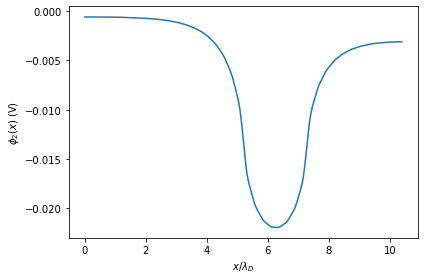

Saved to: outputs\single_case_20260101_135543
{'E_mix': -0.016556839456381228, 'I1': 192.20628712461746, 'I2': -192.20628618289783, 'Itot': 9.417196338290523e-07, 'i_mix': 192.20628712461746, 'K_Au': 5.411927398432047, 'K_Pd': 2.8410798688687664, 'K_ratio': 1.9048839343565922, 'a_weighted_Au': 0.03949648605817168, 'a_weighted_Pd': 0.16707806470380268, 'dlnI1_dE': 18.692236178389283, 'dlnI2_dE': -16.209387375193426, 'di_mix_dE': 3592.765313904653, 'lambda_D_m': 9.619830031440398e-10, 'Lt_total': 10.395194059892011, 'g_Au': 0.034601029503490636, 'g_C': 0.13840411801396255, 'g_Pd': 0.2076061770209438}


In [4]:
def make_output_dir(base="outputs", run_name="run"):
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    out = pathlib.Path(base) / f"{run_name}_{ts}"
    out.mkdir(parents=True, exist_ok=True)
    return out

out_dir = make_output_dir(run_name="single_case")

model = EDLMixedPotentialModel(BASE_PARAMS, N_modes=80, Nx=4000)
E_mix = model.find_E_mix()
summ = model.summary_at_E(E_mix)
df_profile = model.compute_profile(E_mix)

# Save
pd.DataFrame([summ]).to_csv(out_dir/"summary_single.csv", index=False)
df_profile.to_csv(out_dir/"profile_single.csv", index=False)

# Plot: phi2(x) at E_mix
plt.figure()
plt.plot(df_profile["x_tilde"], df_profile["phi2_V"])
plt.xlabel(r"$x/\lambda_D$")
plt.ylabel(r"$\phi_2(x)$ (V)")
plt.tight_layout()
plt.savefig(out_dir/"phi2_profile.png", dpi=300)
plt.show()

print("Saved to:", out_dir)
print(summ)


Cell 5A — 通用 scan 函数（保存 summary.csv + 自动出图）

In [5]:
def scan_parameter(base_params, values, update_fn, N_modes=80, Nx=4000, out_dir=None):
    rows = []
    for v in values:
        p = base_params.copy()
        p = update_fn(p, v)
        model = EDLMixedPotentialModel(p, N_modes=N_modes, Nx=Nx)
        E_mix = model.find_E_mix()
        rows.append({**model.summary_at_E(E_mix), "scan_value": v})

    df = pd.DataFrame(rows)
    if out_dir is not None:
        df.to_csv(out_dir/"summary.csv", index=False)

        # Basic plots
        for y in ["E_mix", "i_mix", "K_ratio", "dlnI1_dE", "di_mix_dE"]:
            plt.figure()
            plt.plot(df["scan_value"], df[y])
            plt.xlabel("scan_value")
            plt.ylabel(y)
            plt.tight_layout()
            plt.savefig(out_dir/f"{y}_vs_scan.png", dpi=300)
            plt.show()
    return df


例 1：支持体/材料参数（扫 pzc_C）只改这一行：lambda p,v: {**p, "pzc_C_V": v}

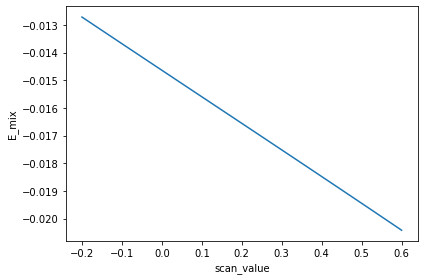

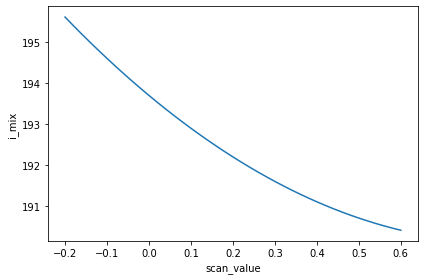

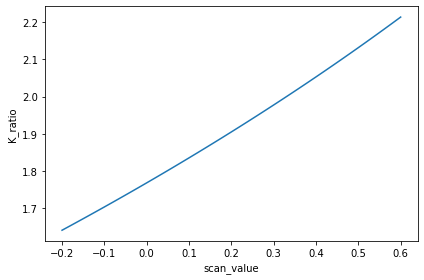

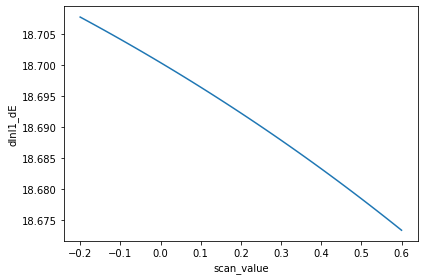

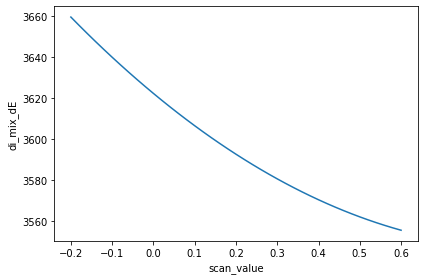

Saved to: outputs\scan_pzc_C_20260101_135544


,E_mix,I1,I2,Itot,i_mix,K_Au,K_Pd,K_ratio,a_weighted_Au,a_weighted_Pd,dlnI1_dE,dlnI2_dE,di_mix_dE,lambda_D_m,Lt_total,g_Au,g_C,g_Pd,scan_value
0,-0.012718,195.618019,-195.618029,-0.000010,195.618019,5.111532,3.115781,1.640530,0.038702,0.166549,18.707701,-16.219681,3659.563468,9.619830e-10,10.395194,0.034601,0.138404,0.207606,-0.20
1,-0.012911,195.407888,-195.407902,-0.000015,195.407888,5.125227,3.100782,1.652882,0.038738,0.166578,18.707000,-16.219126,3655.495332,9.619830e-10,10.395194,0.034601,0.138404,0.207606,-0.18
2,-0.013104,195.202004,-195.202013,-0.000009,195.202004,5.139051,3.085929,1.665317,0.038774,0.166606,18.706291,-16.218575,3651.505558,9.619830e-10,10.395194,0.034601,0.138404,0.207606,-0.16
3,-0.013296,195.000336,-195.000361,-0.000025,195.000336,5.153004,3.071217,1.677838,0.038811,0.166634,18.705576,-16.218029,3647.593531,9.619830e-10,10.395194,0.034601,0.138404,0.207606,-0.14
4,-0.013488,194.802907,-194.802896,0.000011,194.802907,5.167088,3.056646,1.690444,0.038848,0.166662,18.704853,-16.217487,3643.759668,9.619830e-10,10.395194,0.034601,0.138404,0.207606,-0.12


In [6]:
out_dir = make_output_dir(run_name="scan_pzc_C")

values = np.linspace(-0.2, 0.6, 41)  # V
df = scan_parameter(
    BASE_PARAMS,
    values,
    update_fn=lambda p,v: {**p, "pzc_C_V": float(v)},
    out_dir=out_dir
)
print("Saved to:", out_dir)
df.head()


例 2：电解质（扫 ionic strength 或直接扫 λ_D）

(a) 扫 ionic_strength_M：你只改这一行

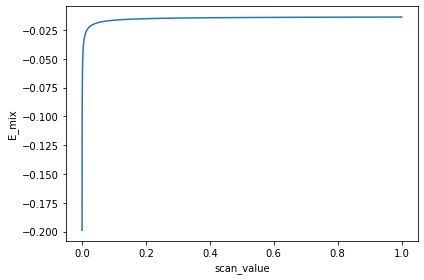

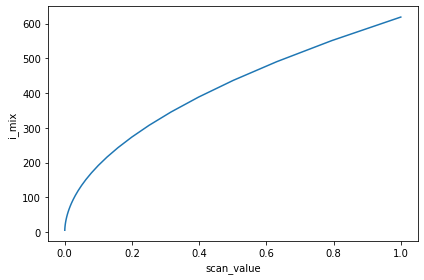

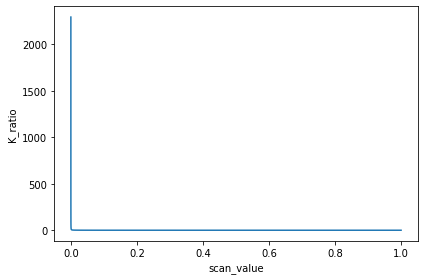

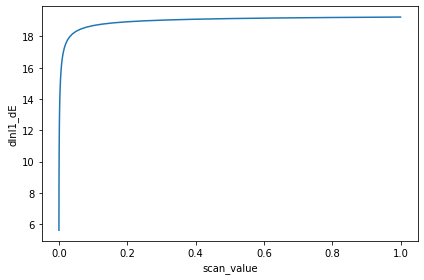

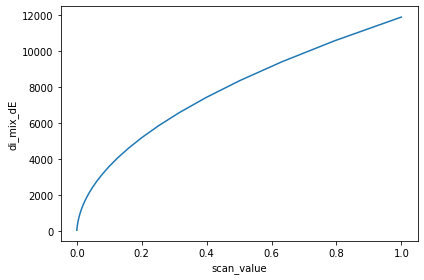

In [7]:
out_dir = make_output_dir(run_name="scan_ionic_strength")

values = np.logspace(-4, 0, 41)  # 1e-4 to 1 M
df = scan_parameter(
    BASE_PARAMS,
    values,
    update_fn=lambda p,v: {**p, "ionic_strength_M": float(v), "lambda_D_m": None},
    out_dir=out_dir
)

(b) 直接扫 Debye length：你只改这一行

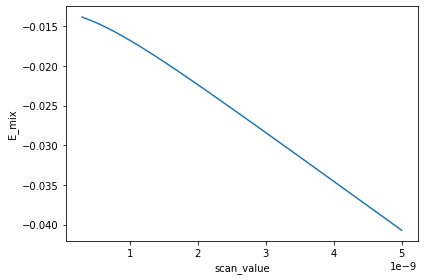

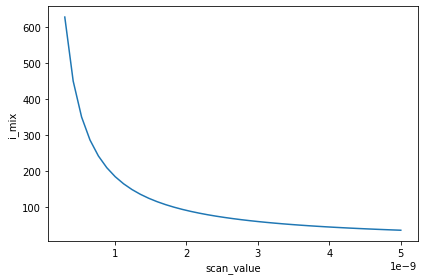

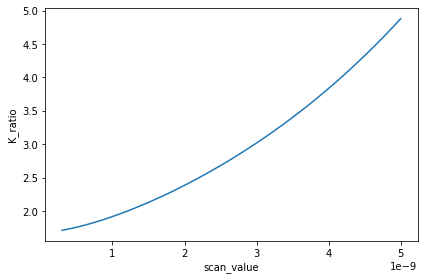

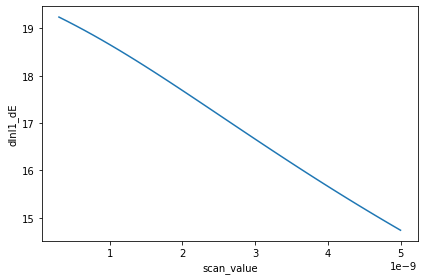

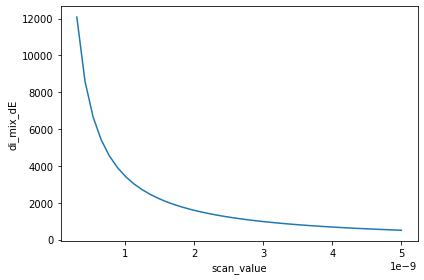

In [8]:
out_dir = make_output_dir(run_name="scan_lambdaD")

values = np.linspace(0.3e-9, 5e-9, 41)  # 0.3–5 nm
df = scan_parameter(
    BASE_PARAMS,
    values,
    update_fn=lambda p,v: {**p, "lambda_D_m": float(v)},  # ionic_strength_M ignored
    out_dir=out_dir
)

例 3：particle size effect（粒径）+ spacing（间距）

(A) 只放大/缩小颗粒（Au 与 Pd 同比例缩放），gap 固定

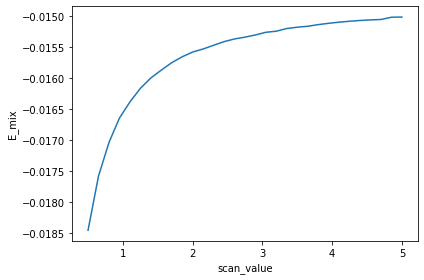

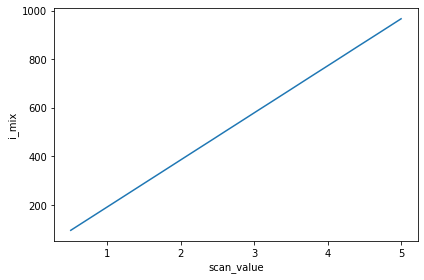

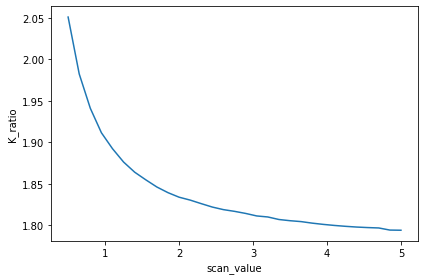

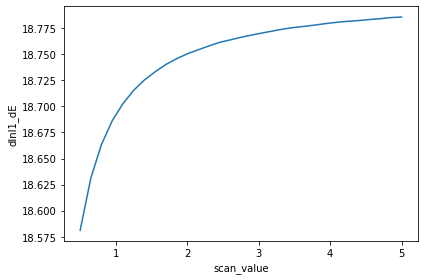

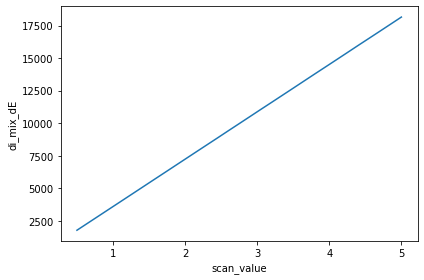

In [9]:
out_dir = make_output_dir(run_name="scan_particle_size_scale")

scales = np.linspace(0.5, 5.0, 31)  # 0.5x to 5x
Au0 = BASE_PARAMS["L_Au_nm"]
Pd0 = BASE_PARAMS["L_Pd_nm"]

df = scan_parameter(
    BASE_PARAMS,
    scales,
    update_fn=lambda p,s: {**p, "L_Au_nm": float(Au0*s), "L_Pd_nm": float(Pd0*s)},
    out_dir=out_dir
)

(B) 只扫间距（gap），粒径固定

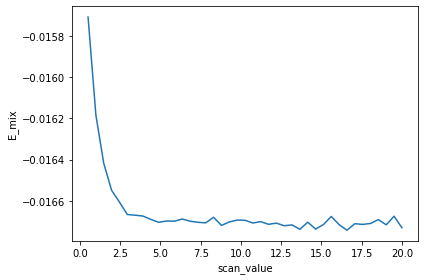

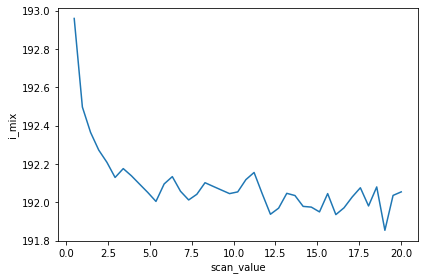

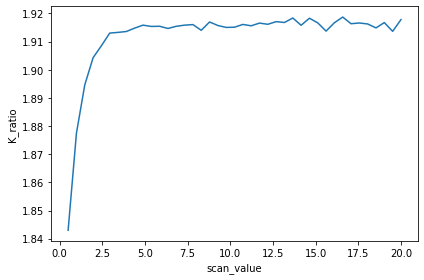

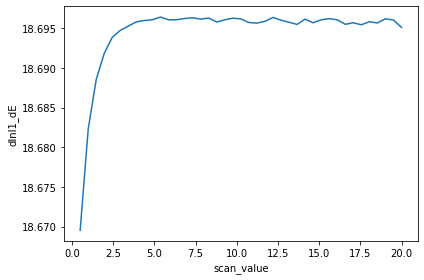

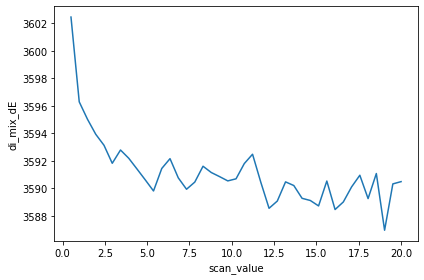

In [10]:
out_dir = make_output_dir(run_name="scan_gap")

gaps = np.linspace(0.5, 20.0, 41)  # nm
df = scan_parameter(
    BASE_PARAMS,
    gaps,
    update_fn=lambda p,g: {**p, "L_gap_nm": float(g)},
    out_dir=out_dir
)